# Titanic Data set from kaggle 
# https://www.kaggle.com/competitions/titanic/data?select=gender_submission.csv

In [1]:
# set paths

data_dir = '/Users/raj/Documents/Corpnce AI/practice/data/titanic/'
test_data = f"{data_dir}/test.csv"
train_data = f"{data_dir}/train.csv"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

test_data = pd.read_csv(test_data)
train_data = pd.read_csv(train_data)

# initial exploration

In [3]:
train_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
print(train_data['Sex'].value_counts())
print(train_data['Pclass'].value_counts())
print(train_data['Embarked'].value_counts())
print(train_data['Survived'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64
Survived
0    549
1    342
Name: count, dtype: int64


In [6]:
print(train_data.groupby('Sex')['Survived'].mean())
print(train_data.groupby('Pclass')['Survived'].mean())
print(train_data.groupby('Embarked')['Survived'].mean())

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [7]:
train_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# nothing to look at passenger ID
# Survived is the target
# Pclass
    - check the impact of the class on survived
    - check the impact of class on survived including gender
    - check the impact of class on survived including family (sibsp +  Parch)
# Name, nothing can be done
# Sex, survival by category
# Age, survival by group may be 10 years
# SibSp, Fare calculation
# parch, Fare calculation
# Ticket, nothing can be done
# Fare, total relation to family and class 
# Embarked, one hot encoding

In [8]:
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
train_data.duplicated().sum()

np.int64(0)

In [10]:
import seaborn as sns

corr = train_data.corr(numeric_only=True)
print(corr)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


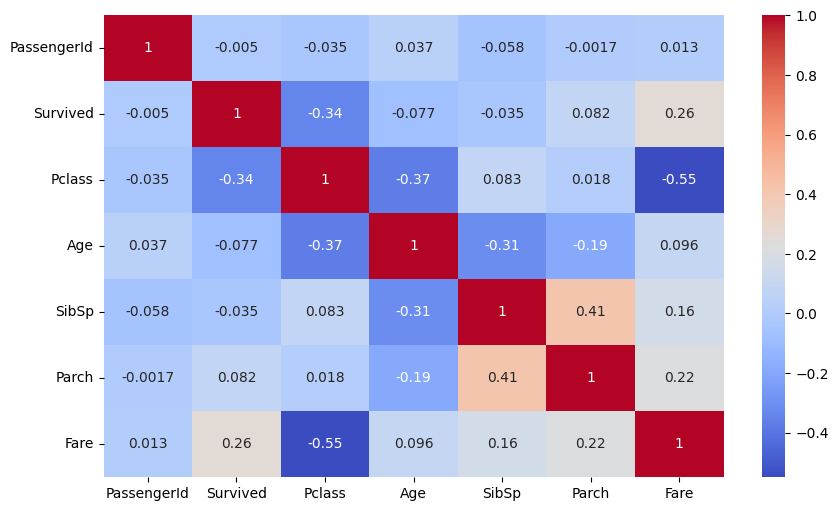

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

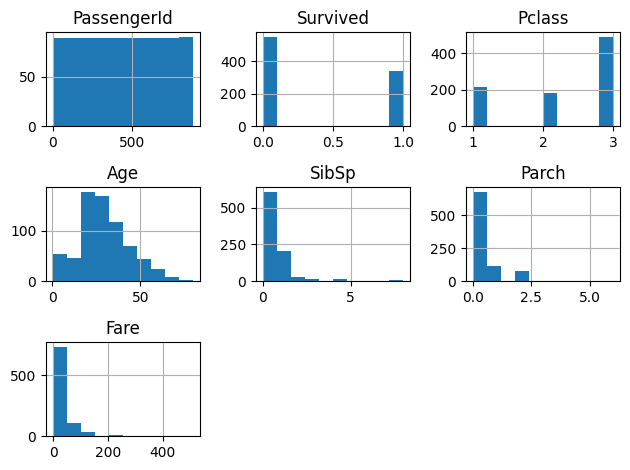

In [12]:
train_data.hist()
plt.tight_layout()
plt.show()

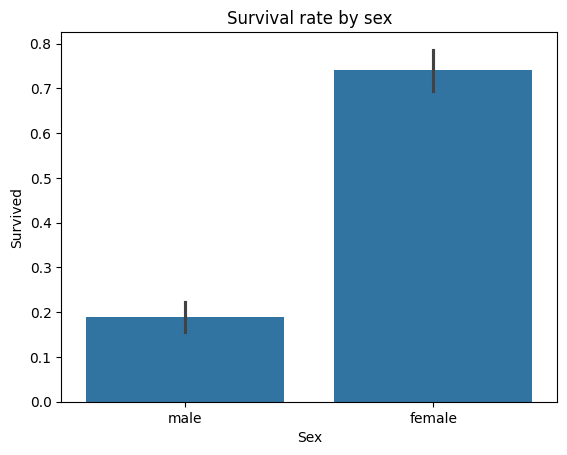

In [13]:


sns.barplot(x='Sex', y='Survived', data=train_data)
plt.title("Survival rate by sex")
plt.show()

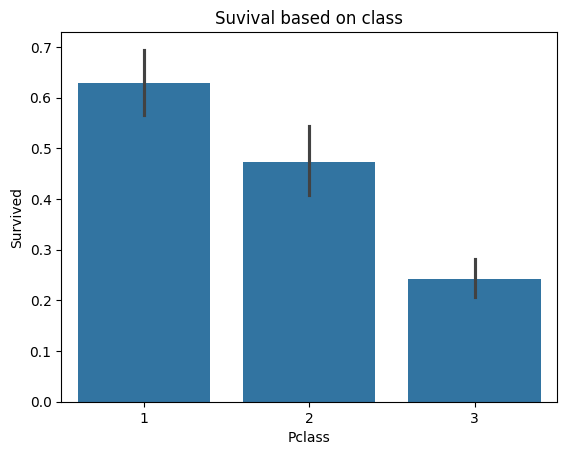

In [14]:
sns.barplot(x='Pclass', y='Survived', data=train_data)
plt.title("Suvival based on class")
plt.show()

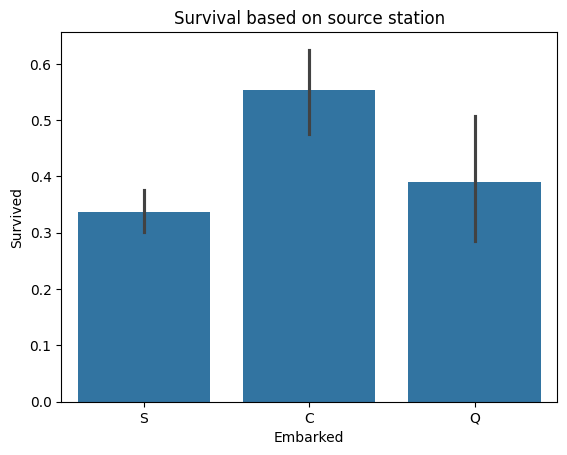

In [15]:
sns.barplot(x='Embarked', y='Survived', data=train_data)
plt.title("Survival based on source station")
plt.show()

<Axes: xlabel='Age', ylabel='Count'>

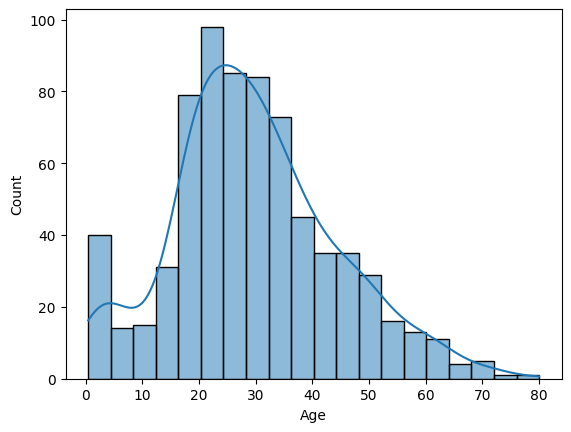

In [16]:
sns.histplot(train_data['Age'], kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

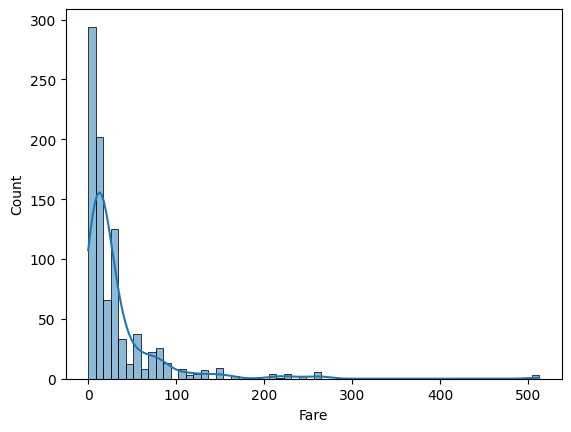

In [17]:
sns.histplot(train_data['Fare'], kde=True)


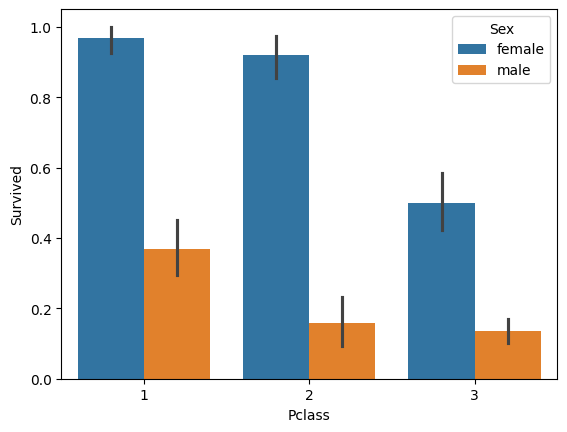

In [18]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=train_data)
plt.show()

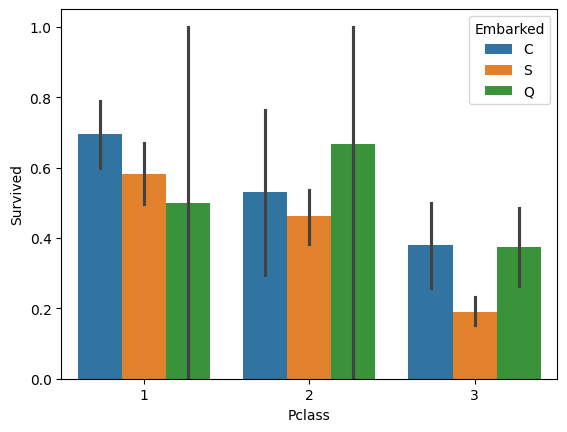

In [19]:
sns.barplot(x='Pclass', y='Survived', hue='Embarked', data=train_data)
plt.show()

In [20]:
# train_data['Family'] = train_data['SibSp'] + train_data['Parch']
# sns.barplot(x='Family', y='Survived', data=train_data)

In [21]:
X = train_data.drop(columns=['Survived'], axis=1)
y = train_data['Survived']

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [23]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['FamilySize'] = X['SibSp'] + X['Parch'] + 1

        X['IsAlone'] = (X['FamilySize'] == 1).astype(int)

        X['AgeGroup'] = pd.cut(X['Age'], bins=[0,12,18,35,60,100])

        X['FareGroup'] = pd.qcut(X['Fare'], 4)

        # X['Title'] = X['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
        def clean_title(title):
            if title in ['Mr']:
                return 'Mr'
            elif title in ['Miss', 'Mlle']:
                return 'Miss'
            elif title in ['Mrs', 'Mme']:
                return 'Mrs'
            elif title in ['Master']:
                return 'Master'
            else:
                return 'Rare'

        X['Title'] = X['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
        X['Title'] = X['Title'].apply(clean_title)

        return X
        

In [24]:
num_col = X.select_dtypes(include="number").columns
cat_col = X.select_dtypes(exclude='number').columns

num_col = list(num_col)
cat_col = list(cat_col)

num_col.extend(['FamilySize'])
cat_col.extend(['IsAlone', 'AgeGroup', 'FareGroup', 'Title'])
print(num_col)
print(cat_col)

['PassengerId', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked', 'IsAlone', 'AgeGroup', 'FareGroup', 'Title']


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2
)
print(X_train.shape)
print(X_test.shape)
print(y_test.shape)
print(y_train.shape)

(712, 11)
(179, 11)
(179,)
(712,)


In [26]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_col),
    ('cat', cat_pipeline, cat_col)
])



In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix

model = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessing', preprocessor),
    ('classifier', LogisticRegression())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

0.8212290502793296
[[90 15]
 [17 57]]


In [28]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5)

print(scores.mean())
print(scores.std())

0.8384615384615385
0.01906456184058427


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessing', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=100))
])

In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessing', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42
    ))
])

In [32]:
from sklearn.neighbors import KNeighborsClassifier

knc_model = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

In [33]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ('feature_engineering', FeatureEngineer()),
    ('preprocessing', preprocessor),
    ('classifier', SVC(probability=True))
])

In [40]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic": model,
    "RandomForest": rf_model,
    "GradientBoost": gb_model,
    "KNN": knc_model,
    "SVM": svm_model
}

for name, m in models.items():
    scores = cross_val_score(m, X_train, y_train, cv=5)
    print(f"{name} -- mean: {scores.mean()} ----  std = {scores.std()}")

Logistic -- mean: 0.8384615384615385 ----  std = 0.01906456184058427
RandomForest -- mean: 0.8342263370432385 ----  std = 0.01849395386004844
GradientBoost -- mean: 0.8229882793263075 ----  std = 0.02094251904837205
KNN -- mean: 0.8032995173840245 ----  std = 0.03209744087967398
SVM -- mean: 0.8328178863390132 ----  std = 0.017872172314154597
